<font size="8">Práctica 3<br>
---------------------------------------------------------------------- Predicción de propiedades moleculares mediante un modelo de machine learning</font>


**Equipo de trabajo**

- Juan Antonio Peregrina
- Sergio Díaz
- Alejandro Figari
- Jorge Ángel Vázquez
- Javier Rozalén
- Gabriel Lazovsky

# Contenido

1. Introducción
2. Implementación del código
    1. Pasos previos
    2. Preprocesamiento de los datos
    3. Entrenamiento del modelo y estimación del error
        - Otros modelos probados        
    4. Generación de predicciones y exportación de resultados
3. Análisis de los resultados
    1. Predicciones vs. Valores reales en el conjunto de validación
    2. Errores vs. Predicciones en el conjunto de validación
    3. Distribución de Predicciones vs. Valores reales en el conjunto de validación
    4. Importancia de características
4. Conclusiones

# 1. Introducción

En el ámbito de la química computacional y el aprendizaje automático, la predicción de propiedades moleculares ha surgido como una herramienta fundamental para acelerar procesos en áreas como el desarrollo de fármacos y la identificación de compuestos químicos. Entre estas propiedades, la Collision Cross Section (CCS) es particularmente relevante en espectrometría de masas, ya que describe cómo interactúan las moléculas con partículas en su entorno. La CCS es clave para identificar moléculas desconocidas comparando sus valores medidos con bases de datos de referencia. Sin embargo, los procedimientos experimentales para medir la CCS suelen ser costosos y laboriosos.

Esta práctica tiene como objetivo desarrollar un modelo de aprendizaje automático capaz de predecir la CCS de nuevas moléculas, utilizando como base datos preprocesados que incluyen descriptores moleculares, fingerprints estructurales y características categóricas. La implementación de un modelo predictivo robusto permitirá optimizar recursos en laboratorios, facilitar la identificación molecular y ampliar las bases de datos de referencia con valores calculados de CCS.

A lo largo de este trabajo se presentan las técnicas empleadas para el preprocesamiento de los datos, el entrenamiento y ajuste de un modelo, la estimación del error cometido sobre un conjunto de validación empleando como métrica el Median Absolute Error (MEDAE) y la generación de predicciones y exportación de los resultados.

Durante el desarrollo de la práctica se probaron dos modelos (**RandomForestRegressor** y **LightGBM**) y distintas técnicas de optimización de hiperparámetros (**GridSearchCV** y **RandomizedSearchCV**). Asimismo, se realizó una selección de características empleando el modelo **LassoCV**.

Finalmente, se realiza un análisis de resultados, se evalúan las limitaciones encontradas, posibles mejoras y lecciones aprendidas.

# 2. Implementación del código

## 2.1. Pasos previos

Previamente a la ejecución del resto del código, en esta sección se completan los siguientes pasos:
1. Importación de las librerías necesarias para todo el código
1. Definición de variables globales
1. Carga de los archivos ``csv`` de entrada

In [12]:
# 2.1.1. Importación de librerías

import os
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LassoCV
from sklearn.metrics import median_absolute_error
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Ocultamos mensajes de advertencia
warnings.filterwarnings('ignore')

In [ ]:
# 2.1.2. Definición de variables globales
  
# Rutas de los archivos
train_file_path = "data/public_train.csv"
test_file_path = "data/public_test.csv"
output_path = "test_preds.csv"

# Hiperparámetros a probar con RandomForest
rf_param_grid = {'n_estimators': [100, 200, 300, 500],
                 'max_depth': [None, 10, 20, 30],
                 'min_samples_split': [2, 5, 10],
                 'min_samples_leaf': [1, 2, 4],
                 'bootstrap': [True, False]}

# Hiperparámetros a probar con LightGBM
lgbm_param_grid = {'n_estimators': [100, 200, 300, 500, 800],
                   'learning_rate': [0.01, 0.05, 0.1, 0.15],
                   'max_depth': [6, 8, 10, 12, 15],
                   'num_leaves': [31, 63, 127],
                   'min_child_samples': [20, 50],
                   'subsample': [0.6, 0.8, 1.0],
                   'colsample_bytree': [0.6, 0.8, 1.0],
                   'reg_alpha': [0, 0.1, 1.0],
                   'reg_lambda': [0, 0.1, 1.0]}

In [ ]:
# 2.1.3. Carga de los archivos de entrada (train y test) a DataFrames

# Verificar si los archivos existen
try:
    if not os.path.exists(train_file_path):
        raise FileNotFoundError(f"El archivo no existe: {train_file_path}")
    if not os.path.exists(test_file_path):
        raise FileNotFoundError(f"El archivo no existe: {test_file_path}")

    train_data = pd.read_csv(train_file_path)
    test_data = pd.read_csv(test_file_path)
    print("Datos cargados correctamente.")

except Exception as e:
    print(f"Error al cargar los archivos: {e}")
    raise e

Datos cargados correctamente.



---


## 2.2. Preprocesamiento de los datos

Una vez cargados los archivos, procesamos los datos antes del entrenamiento del modelo. Este preprocesamiento comprende los siguientes pasos:
1. Separación de los datos de entrenamiento entre ``X`` e ``y``
1. Identificación de columnas categóricas y numéricas, a las que deben aplicarse imputadores y transformadores diferentes
1. Agrupación de los preprocesadores mediante Pipelines, y aplicación de las transformaciones a los datos
1. Separación de los datos de entrenamiento entre conjunto ``train`` y ``val``, que serán usados por el modelo
1. Selección de características relevantes

In [ ]:
# 2.2.1. Separamos los datos en X e y
X = train_data.drop(columns=['ccs'])
y = train_data['ccs']


# 2.2.2. Identificamos columnas con datos categóricos y numéricos
categorical_cols = ['adduct']
numerical_cols = [col for col in X.columns if col not in categorical_cols]


# 2.2.3. Instanciamos imputadores, escalador y codificador y agrupamos en Pipelines

# Instanciamos dos imputadores para eliminar NaNs: media a datos numéricos y más frecuente a categóricos
numeric_imputer = SimpleImputer(strategy="mean")
categorical_imputer = SimpleImputer(strategy="most_frequent")

# Instanciamos un escalador para normalizar los datos numéricos
scaler = StandardScaler()

# Instanciamos un codificador OneHot para las columnas categóricas
oh_encoder = OneHotEncoder(sparse_output=False)

# Creamos un preprocesador que aplica las transformaciones a columnas numéricas
numeric_transformer = Pipeline(steps=[("imputer", numeric_imputer),
                                      ("scaler", scaler)])

# Creamos un preprocesador que aplica las transformaciones a columnas categóricas
categorical_transformer = Pipeline(steps=[("imputer", categorical_imputer),
                                          ("encoder", oh_encoder)])

# Combinamos los preprocesadores en un ColumnTransformer
transformer = ColumnTransformer(
    transformers=[('numeric_imp', numeric_transformer, numerical_cols),
                  ('categorical_imp', categorical_transformer, categorical_cols)])


# Aplicamos las transformaciones a los datos: fit_transform para train y transform para test
X_train_preprocessed = transformer.fit_transform(X)
X_test_preprocessed = transformer.transform(test_data)


# 2.2.4. Dividimos los datos en train y validation
X_train_split, X_val, y_train_split, y_val = train_test_split(X_train_preprocessed, y, test_size=0.2, random_state=42)

print("Datos preprocesados correctamente.")

Datos preprocesados correctamente.


El siguiente paso realiza la **selección de características** relevantes para mejorar el rendimiento del modelo. Se hace la selección de características mediante un modelo **LassoCV**. Este paso es opcional, pero mejora notablemente el tiempo de entrenamiento de los modelos sin sacrificar la precisión en las predicciones.

In [ ]:
# 2.2.5. Selección de características utilizando LassoCV (paso opcional)

# Entrenamos el modelo LassoCV
lasso = LassoCV(cv=5)
lasso.fit(X_train_split, y_train_split)

# Seleccionamos las características relevantes utilizando el modelo LassoCV entrenado y transformamos
# los datos de entrenamiento, validación y test. Utilizamos los mismos nombres de variables para no
# tener que modificar el resto del código.
feature_selector = SelectFromModel(lasso, prefit=True)
X_train_split = feature_selector.transform(X_train_split)
X_val = feature_selector.transform(X_val)
X_test_preprocessed = feature_selector.transform(X_test_preprocessed)

print("Características seleccionadas correctamente.")
print("Características antes de la selección:", X_train_preprocessed.shape[1])
print("Características después de la selección:", X_train_split.shape[1])

Características seleccionadas correctamente.
Características antes de la selección: 1946
Características después de la selección: 473



---


## 2.3. Entrenamiento del modelo y estimación del error

Durante el desarrollo de la práctica hemos probado los modelos **RandomForestRegressor** y **LightGBM**. Para ambos modelos hemos probado su entrenamiento con los hiperparámetros predeterminados, así como la optimización de hiperparámetros con **GridSearchCV** y **RandomizedSearchCV**.

También se han probado distintas configuraciones de matrices de hiperparámetros y de otros parámetros como número de folds e iteraciones.

Finalmente, el modelo que demostró mayor precisión (menor MEDAE) con tiempo de ejecución moderado, fue **LightGBM** combinado con **RandomizedSearchCV** para el ajuste de hiperparámetros, que es el modelo que se muestra a continuación.

**LightGBM** (*Light Gradient Boosting Machine*) es un algoritmo de aprendizaje supervisado basado en *gradient boosting* diseñado para ser rápido, eficiente y escalable. Es ideal para problemas de clasificación y regresión, y destaca en datasets grandes o de alta dimensionalidad.

El modelo **RandomForestRegressor** entrena un conjunto de árboles de decisión en paralelo. Combina múltiples árboles entrenados en diferentes subconjuntos de datos y características (*ensembles*) para mejorar la precisión y reducir el sobreajuste.

**GridSearchCV** es una técnica de optimización de hiperparámetros en machine learning que realiza una búsqueda exhaustiva sobre una matriz de posibles hiperparámetros de un modelo. Combina la búsqueda en rejilla (*grid search*) con validación cruzada (*cross-validation*) para garantizar que el modelo se evalúe de manera robusta.

**RandomizedSearchCV** es una técnica de optimización de hiperparámetros que selecciona combinaciones aleatorias de valores en lugar de explorar exhaustivamente todas las posibles combinaciones (a diferencia de **GridSearchCV**). Esto permite explorar un espacio de búsqueda más amplio con menos coste computacional. Utiliza validación cruzada para evaluar cada combinación de forma robusta y evitar sobreajuste.

In [ ]:
# 2.3. LightGBM con optimización de hiperparámetros usando RandomizedSearchCV

# Instanciamos el modelo
model_prev = LGBMRegressor(random_state=42)

# Utilizamos RandomizedSearchCV para encontrar los hiperparámetros que minimicen la MEDAE
search = RandomizedSearchCV(estimator=model_prev,
                            param_distributions=lgbm_param_grid,
                            scoring='neg_median_absolute_error',
                            cv=5,
                            n_iter=100,
                            n_jobs=-1,
                            random_state=42)

search.fit(X_train_split, y_train_split)

# model: modelo entrenado con los mejores hiperparámetros
model = search.best_estimator_

# Imprime los mejores parámetros
print("Mejores hiperparámetros LGBM:", search.best_params_)

# Validamos el modelo con el conjunto de validación y calculamos el error MEDAE
predictions_val = model.predict(X_val)
medae_train = median_absolute_error(y_val, predictions_val)
print(f"MEDAE con LightGBM optimizado: {medae_train:.2f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.023452 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 42877
[LightGBM] [Info] Number of data points in the train set: 6648, number of used features: 456
[LightGBM] [Info] Start training from score 200.154403
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

### Otros modelos probados

A continuación se muestran otras implementaciones de LightGBM y RandomForest probadas durante el desarrollo de la práctica.

No es necesario ejecutar estas celdas. Con ejecutar el modelo anterior, se puede proceder con la generación de resultados. Estos modelos están implementados para pruebas, no para su ejecución secuencial.

Con el objetivo de comparar el rendimiento (en tiempo de ejecución y MEDAE) de los diferentes modelos, se han probado 6 implementaciones diferentes:
1. RandomForest
    1. Sin optimización de hiperparámetros
    1. Con optimización de hiperparámetros usando GridSearchCV
    1. Con optimización de hiperparámetros usando RandomizedSearchCV
1. LightGBM
    1. Sin optimización de hiperparámetros
    1. Con optimización de hiperparámetros usando GridSearchCV
    1. Con optimización de hiperparámetros usando RandomizedSearchCV (mejor modelo; implementado arriba)

Asimismo, se ha probado cada combinación tanto sin selección de características como aplicando selección de características.

*Nota: las celdas de código a continuación son, en realidad, celdas de Markdown. Esto se ha hecho para permitir la ejecución completa del Notebook con la combinación final elegida. En caso de querer ejecutar alguna de las celdas siguientes, es necesario copiar el código a una nueva celda.*

#### **RandomForest**

##### **RandomForest** sin optimización de hiperparámetros

```python
# RandomForest sin optimización de hiperparámetros

# Instanciamos el modelo y lo entrenamos
model = RandomForestRegressor(random_state=42)
model.fit(X_train_split, y_train_split)
print("Modelo entrenado con éxito.")

# Validamos el modelo con el conjunto de validación y calculamos el error MEDAE
predictions_val = model.predict(X_val)
medae_train = median_absolute_error(y_val, predictions_val)
print(f"MEDAE RandomForest: {medae_train:.2f}")

##### **RandomForest** con optimización de hiperparámetros usando **GridSearchCV**

```python
# RandomForest con optimización de hiperparámetros usando GridSearchCV

# Instanciamos el modelo
model_prev = RandomForestRegressor(random_state=42)

# Utilizamos GridSearchCV para encontrar los hiperparámetros que minimicen la MEDAE
search = GridSearchCV(estimator=model_prev,
                      param_grid=rf_param_grid,
                      cv=5,
                      scoring='neg_median_absolute_error',
                      n_jobs=-1)

search.fit(X_train_split, y_train_split)

# model: modelo entrenado con los mejores hiperparámetros
model = search.best_estimator_

# Imprime los mejores parámetros
print("Mejores hiperparámetros RandomForest:", search.best_params_)

# Validamos el modelo con el conjunto de validación y calculamos el error MEDAE
predictions_val = model.predict(X_val)
medae_train = median_absolute_error(y_val, predictions_val)
print(f"MEDAE RandomForest optimizado: {medae_train:.2f}")

##### **RandomForest** con optimización de hiperparámetros usando **RandomizedSearchCV**

```python
# RandomForest con optimización de hiperparámetros usando RandomizedSearchCV

# Instanciamos el modelo
model_prev = RandomForestRegressor(random_state=42)

# Utilizamos RandomizedSearchCV para encontrar los hiperparámetros que minimicen la MEDAE
search = RandomizedSearchCV(estimator=model_prev,
                            param_distributions=rf_param_grid,
                            scoring='neg_median_absolute_error',
                            cv=5,
                            n_iter=100,
                            n_jobs=-1,
                            random_state=42)

search.fit(X_train_split, y_train_split)

# model: modelo entrenado con los mejores hiperparámetros
model = search.best_estimator_

# Imprime los mejores parámetros
print("Mejores hiperparámetros RandomForest:", search.best_params_)

# Validamos el modelo con el conjunto de validación y calculamos el error MEDAE
predictions_val = model.predict(X_val)
medae_train = median_absolute_error(y_val, predictions_val)
print(f"MEDAE RandomForest optimizado: {medae_train:.2f}")

#### **LightGBM**

##### **LightGBM** sin optimización de hiperparámetros

```python
# LightGBM sin optimización de hiperparámetros

# Instanciamos el modelo y lo entrenamos
model = LGBMRegressor(random_state=42)
model.fit(X_train_split, y_train_split)
print("Modelo entrenado con éxito.")

# Validamos el modelo con el conjunto de validación y calculamos el error MEDAE
predictions_val = model.predict(X_val)
medae_train = median_absolute_error(y_val, predictions_val)
print(f"MEDAE con LightGBM: {medae_train:.2f}")

##### **LightGBM** con optimización de hiperparámetros usando **GridSearchCV**

```python
# LightGBM con optimización de hiperparámetros usando GridSearchCV

# Instanciamos el modelo
model_prev = LGBMRegressor(random_state=42)

# Utilizamos GridSearchCV para encontrar los hiperparámetros que minimicen la MEDAE
search = GridSearchCV(estimator=model_prev,
                      param_grid=lgbm_param_grid,
                      cv=5,
                      scoring='neg_median_absolute_error',
                      n_jobs=-1)

search.fit(X_train_split, y_train_split)

# model: modelo entrenado con los mejores hiperparámetros
model = search.best_estimator_

# Imprime los mejores parámetros
print("Mejores hiperparámetros LGBM:", search.best_params_)

# Validamos el modelo con el conjunto de validación y calculamos el error MEDAE
predictions_val = model.predict(X_val)
medae_train = median_absolute_error(y_val, predictions_val)
print(f"MEDAE con LightGBM optimizado: {medae_train:.2f}")

##### **LightGBM** con optimización de hiperparámetros usando **RandomizedSearchCV**

Este es el modelo que demostró mejor rendimiento y, por tanto, el que aparece reflejado en el apartado ``2.3``


---


## 2.4. Generación de predicciones y exportación de resultados

En esta sección, se calculan las predicciones de CCS correspondientes a los datos de ``test`` y se exportan al fichero ``test_preds.csv`` con 5 decimales, tal y como aparecen estos valores en el conjunto de entrenamiento.

Las predicciones se calcularán con el último modelo entrenado en el apartado anterior (en caso de haber ejecutado otro modelo distinto del reflejado en el apartado ``2.3``).

In [ ]:
# 2.4. Exportación de predicciones

# Predecimos los valores CCS para el conjunto de test
predictions_test = model.predict(X_test_preprocessed)

# Guardamos predicciones en archivo CSV, con 5 decimales (como en los datos de entrenamiento)
pd.DataFrame(predictions_test).to_csv(output_path, index=False, header=False, float_format='%.5f')

print(f"Fichero de predicciones guardado en: {output_path}")

Fichero de predicciones guardado en: test_preds.csv


# 3. Análisis de los resultados

## 3.1. Predicciones vs. Valores reales en el conjunto de validación

En el siguiente gráfico se muestran, en el eje de abscisas, las predicciones del conjunto de validación, y en el eje de ordenadas, los valores reales correspondientes.

Con un modelo perfectamente entrenado, los puntos deberían formar una recta ``y=x``.

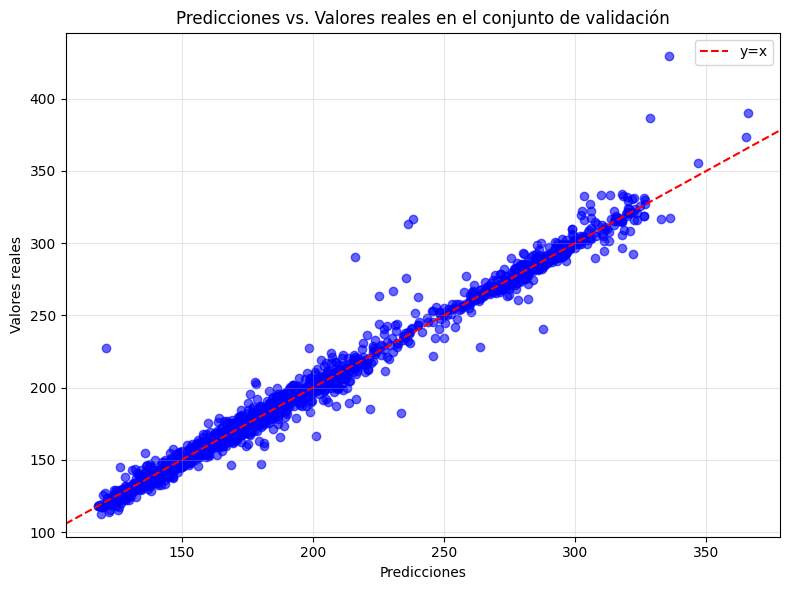

In [ ]:
# 3.1. Predicciones vs. Valores reales en el conjunto de validación

plt.figure(figsize=(8, 6))
plt.scatter(predictions_val, y_val, alpha=0.6, color='blue')
plt.axline((200, 200), slope=1, color='r', linestyle='--', label='y=x')
plt.xlabel("Predicciones")
plt.ylabel("Valores reales")
plt.title("Predicciones vs. Valores reales en el conjunto de validación")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El gráfico nos enseña una comparativa entre los valores estimados por el modelo y los valores reales en un conjunto de validación.

Del gráfico destacamos:

- La alineación de los puntos a lo largo de la recta y=x, por lo que podemos concluir que el modelo presenta un buen desempeño.
- Como se puede observar, a pesar de estar alineados, hay algunos valores fuera de la línea que ponen de manifiesto los errores cometidos por el modelo.
- La dispersión de los errores muestra que el modelo no tiene un sesgo significativo hacia una subestimación o sobreestimación sistemática.
- Respecto de los puntos más alejados de la diagonal, concluimos que son errores aislados que requerirían un análisis adicional.

## 3.2. Errores vs. Predicciones en el conjunto de validación

Este diagrama, similar al anterior, muestra la relación entre las predicciones del modelo y los errores cometidos para el conjunto de validación.

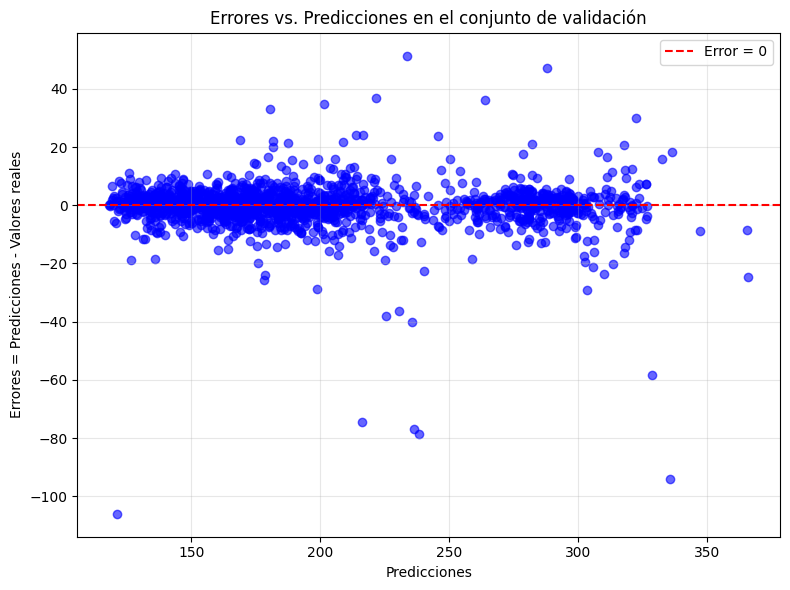

In [ ]:
# 3.2. Errores vs. Predicciones en el conjunto de validación

plt.figure(figsize=(8, 6))
plt.scatter(predictions_val, predictions_val-y_val, alpha=0.6, color='blue')
plt.axhline(0, color='r', linestyle='--', label='Error = 0')
plt.xlabel('Predicciones')
plt.ylabel('Errores = Predicciones - Valores reales')
plt.title('Errores vs. Predicciones en el conjunto de validación')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Las conclusiones que pueden extraerse de este gráfico son similares a las del anterior. Si acaso, podría observarse un mayor sesgo hacia la subestimación que a la sobreestimación.

## 3.3. Distribución de Predicciones vs. Valores reales en el conjunto de validación

Este diagrama muestra un histograma de las predicciones y los valores reales del conjunto de validación.

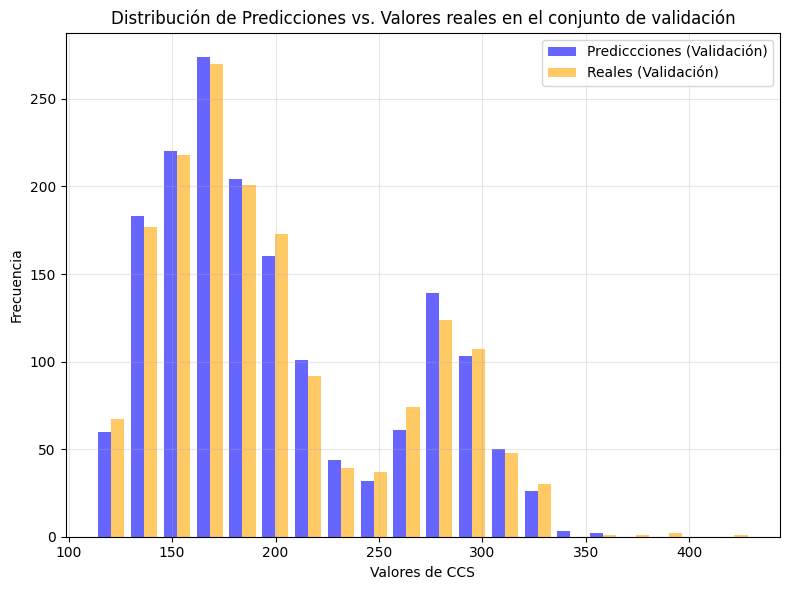

In [ ]:
# 3.3. Distribución de Predicciones vs. Valores reales en el conjunto de validación

plt.figure(figsize=(8, 6))
plt.hist([predictions_val, y_val], color=['blue', 'orange'],
         label=['Prediccciones (Validación)', 'Reales (Validación)'],
         alpha=0.6, bins=20)
plt.xlabel('Valores de CCS')
plt.ylabel('Frecuencia')
plt.title("Distribución de Predicciones vs. Valores reales en el conjunto de validación")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

En este gráfico, se observa una ligera tendencia del modelo a concentrar las estimaciones en torno a los valores más frecuentes (aproximadamente 165 y 280), mientras reduce el número de estimaciones en los valores menos frecuentes (125 y 250).

## 3.4. Importancia de características

Este gráfico muestra la importancia relativa de las características en el modelo de regresión. Las barras horizontales representan la importancia asignada a cada característica, ordenadas de mayor a menor, lo que permite identificar cuáles contribuyen más al desempeño del modelo. El eje vertical enumera las características y el eje horizontal muestra la medida cuantitativa de la importancia, basada en cómo cada característica mejora la predicción del modelo.

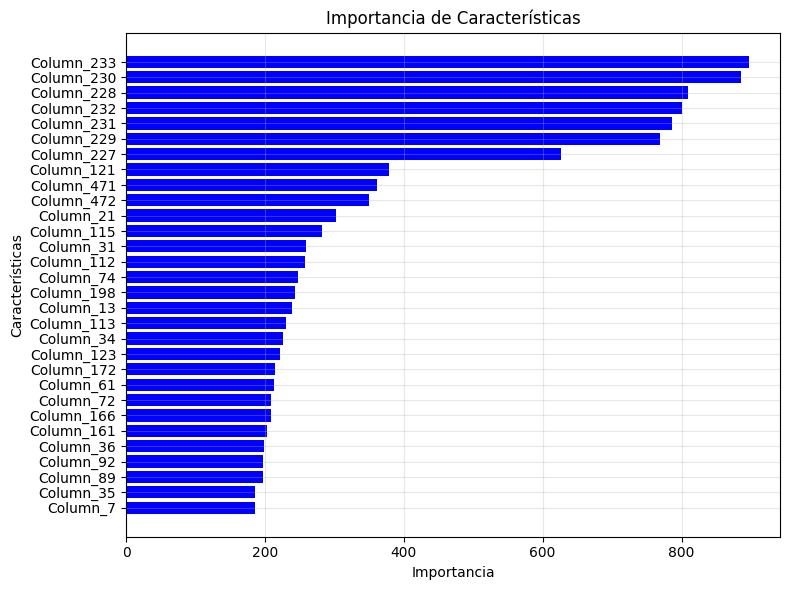

In [ ]:
# 3.4. Importancia de características

# Obtener la importancia de las características
importance = model.feature_importances_
features = model.feature_names_in_

# Crear un DataFrame para la importancia de características
feature_importance_df = pd.DataFrame({'feature': features, 'importance': importance})

# Ordenar por importancia y seleccionar las top 25
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False).head(30)

# Plotear la importancia de características
plt.figure(figsize=(8, 6))
plt.barh(feature_importance_df['feature'], feature_importance_df['importance'], color='blue')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.title('Importancia de Características')
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

En el gráfico se ve cómo hay 7 características que tienen un peso muy relevante en el funcionamiento del modelo. A partir de ahí, la importancia relativa se reduce paulatinamente.

# 4. Conclusiones

Para el desarrollo de la práctica elegimos los modelos **RandomForest** y **LightGBM** porque eran mencionados con frecuencia en literatura científica relacionada con machine learning y descriptores moleculares. Por ejemplo:

- [Automatic Selection of Molecular Descriptors using Random Forest: Application to Drug Discovery](https://www.researchgate.net/publication/311483041_Automatic_Selection_of_Molecular_Descriptors_using_Random_Forest_Application_to_Drug_Discovery)

- [Practical guidelines for the use of gradient boosting for molecular property prediction](https://jcheminf.biomedcentral.com/articles/10.1186/s13321-023-00743-7)

- [Gene selection and classification of microarray data using random forest](https://bmcbioinformatics.biomedcentral.com/articles/10.1186/1471-2105-7-3)

**RandomForest** destaca por su robustez y simplicidad, si bien está indicado para datasets pequeños o medianos. **LightGBM** se caracteriza por su eficiencia y velocidad y su capacidad para trabajar con datasets grandes o de alta dimensionalidad.

Comenzamos probando ambos algoritmos con sus hiperparámetros predeterminados y sin hacer selección de características previa. Los tiempos de ejecución iniciales fueron de 10 minutos para **RandomForest** y de unos 10 segundos para **LightGBM**, obteniendo MEDAE's de 3.05 y 2.78, respectivamente.

Posteriormente, incorporamos la selección de características mediante un modelo **LassoCV** que redujo el número de características de 1.943 a 476, requiriendo un tiempo de ejecución de unos 30 segundos. Esta selección de variables previa aceleró notablemente la velocidad de entrenamiento de los modelos sin sacrificar la precisión. Los tiempos de ejecución se redujeron a 2 minutos para **RandomForest**, y a 2 segundos para **LightGBM**, con unos MEDAE's de 3.06 y 2.75, respectivamente. Es decir, los tiempos de ejecución disminuyeron en un 80% sin impacto negativo significativo en los resultados.

Finalmente, y con el objetivo de mejorar la precisión de los modelos, incorporamos la optimización de hiperparámetros usando **GridSearchCV** y **RandomizedSearchCV**, proporcionándoles unas matrices suficientemente complejas como para probar un buen número de combinaciones de hiperparámetros. Aunque **GridSearchCV** exploró exhaustivamente las combinaciones de hiperparámetros, su coste computacional fue extremadamente elevado, llegando a superar las 10 horas de ejecución en algunos casos. En cambio, **RandomizedSearchCV** ofreció una alternativa mucho más eficiente, especialmente al combinarse con **LightGBM**, logrando un MEDAE de 2.65 en aproximadamente 30 minutos de ejecución.

Este enfoque iterativo en el desarrollo de la práctica nos ha permitido optimizar el balance entre precisión y tiempo de ejecución, destacando la superioridad de **LightGBM** junto a **RandomizedSearchCV** en términos de velocidad y rendimiento global.

### Resultados

A continuación mostramos los resultados detallados en tiempo de ejecución y MEDAE de las distintas combinaciones probadas. La primera tabla muestra los resultados con el dataset completo, mientras que en la segunda se muestran los resultados después de realizar la selección de características.

<center>

|                    |        RandomForest        |          LightGBM          |
|--------------------|:--------------------------:|:--------------------------:|
| No optimizado      | Tiempo: 10m<br>MEDAE: 3.05 | Tiempo: 10s<br>MEDAE: 2.78 |
| GridSearchCV       | Tiempo: >5h                | Tiempo: >5h                |
| RandomizedSearchCV | Tiempo: >5h                | Tiempo: >5h                |

</center>

Después de realizar la selección de características mediante **LassoCV**, que redujo el número de características de 1.943 a 476, proceso que consumió 30 segundos, los resultados fueron:

<center>

|                    |        RandomForest       |          LightGBM          |
|--------------------|:-------------------------:|:--------------------------:|
| No optimizado      | Tiempo: 2m<br>MEDAE: 3.06 | Tiempo: 2s<br>MEDAE: 2.75  |
| GridSearchCV       | Tiempo: >5h               | Tiempo: >5h                |
| RandomizedSearchCV | Tiempo: >5h               | Tiempo: 30m<br><mark>MEDAE: 2.65</mark> |

</center>

*La medición de los tiempos de ejecución se ha realizado en un ordenador con un procesador Intel i7 de 3.2 GHz y 16GB de RAM*.

### Limitaciones identificadas

La principal limitación que nos hemos encontrado ha sido la disponibilidad de recursos de computación. El entrenamiento de un modelo, y particularmente con optimización de hiperparámentros, es un proceso intensivo que requiere mucho tiempo de ejecución. Esto dificulta probar distintas configuraciones, obtener resultados y hacer comparaciones de forma ágil.

Por este motivo, nos hemos ceñido a dos modelos y dos algoritmos de optimización de hiperparámetros, combinándolos con selección de características.

### Posibles mejoras
Contando con mayores recursos de computación, habríamos podido explorar más modelos de *Gradient Boosting Machines* (GBMs) para intentar mejorar los resultados ya obtenidos.

Asimismo, podríamos haber probado con matrices de hiperparámetros más complejas con el objetivo de ajustar mejor los modelos.

### Lecciones aprendidas

Para el dataset concreto de la práctica, **LightGBM** demostró un mayor rendimiento tanto en tiempo de ejecución como en precisión.

La selección de características reduce notablemente los tiempos de entrenamiento de los modelos sin sacrificar la precisión de los mismos y no requiriendo tiempos de ejecución elevados. En nuestro caso, la selección de características usando un modelo **LassoCV** requirió unos 30 segundos de computación y redujo el tiempo de entrenamiento del modelo de 10 minutos a 2 minutos (para **RandomForest** sin optimización de hiperparámetros).

La optimización de hiperparámetros mejora significativamente el rendimiento del modelo en términos de precisión, si bien incrementa considerablemente los tiempos de computación.

La utilización de técnicas de optimización de hiperparámetros como **GridSearchCV** o **RandomizedSearchCV** permiten la búsqueda sistemática o aleatoria de las mejores combinaciones de hiperparámentros, a la vez que garantizan la evaluación exhaustiva del modelo mediante la utilización de validación cruzada. No obstante, **RandomizedSearchCV** es notablemente menos costoso en tiempo de ejecución que **GridSearchCV**.